# Force-Aware Agent Comparison

This notebook compares the current archived `force_aware` standard-J training runs against the existing non-force-aware baseline agents from the wire registry.

It is intentionally dynamic: if more force-aware runs are synced into `data/archive/agents/force_aware`, the tables below will include them automatically.

In [1]:
from pathlib import Path
import sys

try:
    import pandas as pd
except ModuleNotFoundError:
    pd = None

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    plt = None

sys.path.insert(0, str(Path('experiments/master-thesis').resolve()))

from notebook_helpers.force_aware import FORCE_AWARE_ROOT, load_force_aware_comparison_rows, to_frame

if pd is not None:
    pd.set_option('display.max_columns', 100)
    pd.set_option('display.max_colwidth', 120)


In [2]:
rows = load_force_aware_comparison_rows()
if pd is not None:
    df = to_frame(rows)
else:
    df = None

print(f'Loaded {len(rows)} comparison rows')
print(f'Force-aware archive root: {FORCE_AWARE_ROOT}')
print(f'pandas available: {pd is not None}')
print(f'matplotlib available: {plt is not None}')

rows


Loaded 12 comparison rows
Force-aware archive root: /home/hannes-deittert/dev/Uni/master-project/data/archive/agents/force_aware
pandas available: True
matplotlib available: True


[{'comparison_group': 'baseline',
  'archive_label': 'archvar_steve_standard_j_best',
  'archive_run_dir': '/home/hannes-deittert/dev/Uni/master-project/data/archive/agents/complete/complete_steve_standard_j/2026-04-25_163824_a100x1_archvar_steve_standardj_cap150_450_full_1583390',
  'summary_csv': '/home/hannes-deittert/dev/Uni/master-project/data/archive/agents/complete/complete_steve_standard_j/2026-04-25_163824_a100x1_archvar_steve_standardj_cap150_450_full_1583390/2026-04-25_163824_a100x1_archvar_steve_standardj_cap150_450_full_1583390.csv',
  'wire_name': 'steve_default',
  'wire_version': 'standard_j',
  'force_alpha_suffix': 'baseline',
  'force_alpha': 0.0,
  'agent_json': '/home/hannes-deittert/dev/Uni/master-project/data/wire_registry/steve_default/wire_versions/standard_j/agents/archvar_steve_standard_j_best/agent.json',
  'source_checkpoint': '/home/hannes-deittert/dev/Uni/master-project/data/archive/agents/complete/complete_steve_standard_j/2026-04-25_163824_a100x1_archva

## Available Runs

The current local archive may still be incomplete. This cell makes that explicit before interpreting the comparison.

In [3]:
columns = [
    'comparison_group',
    'wire_name',
    'force_alpha_suffix',
    'archive_label',
    'archive_run_dir',
]

if pd is None:
    [{column: row.get(column) for column in columns} for row in rows]
else:
    df[columns].sort_values(["comparison_group", "wire_name", "force_alpha_suffix"]).reset_index(drop=True)


## Quick Check Plan

This section builds a small paired evaluation plan on a few fixed anatomies.
Each quick-check job keeps the wire constant and changes only the checkpoint: baseline vs force-aware.
The seed schedule is identical across the pair, so the comparison is controlled.


In [4]:
from notebook_helpers.force_aware import build_quickcheck_rows, load_sample_record_ids

QUICKCHECK_ANATOMIES = load_sample_record_ids(limit=3)
QUICKCHECK_TRIALS = 20
QUICKCHECK_MAX_STEPS = 500
QUICKCHECK_WORKERS = 4

quick_rows = build_quickcheck_rows(
    anatomy_ids=QUICKCHECK_ANATOMIES,
    trial_count=QUICKCHECK_TRIALS,
    max_episode_steps=QUICKCHECK_MAX_STEPS,
    workers=QUICKCHECK_WORKERS,
)

print(f'quick-check anatomies: {QUICKCHECK_ANATOMIES}')
print(f'quick-check jobs: {len(quick_rows)}')
quick_rows[:4]


quick-check anatomies: ['Tree_660', 'Tree_1382', 'Tree_1882']
quick-check jobs: 54


[{'anatomy_id': 'Tree_660',
  'wire_name': 'steve_default',
  'wire_version': 'standard_j',
  'force_alpha_suffix': 'a001',
  'candidate_kind': 'baseline',
  'execution_wire': 'steve_default/standard_j',
  'checkpoint': '/home/hannes-deittert/dev/Uni/master-project/data/wire_registry/steve_default/wire_versions/standard_j/agents/archvar_steve_standard_j_best/checkpoints/best_checkpoint.everl',
  'policy_label': 'steve_default_standard_j_baseline',
  'job_name': 'quick_steve_default_standard_j_a001_baseline_Tree_660',
  'output_dir': '/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/force_aware_quickcheck/quick_steve_default_standard_j_a001_baseline_Tree_660',
  'command': 'python -m steve_recommender.eval_v2.cli run --job-name quick_steve_default_standard_j_a001_baseline_Tree_660 --anatomy Tree_660 --execution-wire steve_default/standard_j --policy-checkpoint /home/hannes-deittert/dev/Uni/master-project/data/wire_registry/steve_default/wire_versions/standard_j/agents/

In [5]:
if pd is None:
    quick_rows
else:
    quick_df = pd.DataFrame(quick_rows)
    quick_df[[
        'anatomy_id',
        'wire_name',
        'force_alpha_suffix',
        'candidate_kind',
        'checkpoint',
        'job_name',
    ]].sort_values(["anatomy_id", "wire_name", "force_alpha_suffix", "candidate_kind"]).reset_index(drop=True)


In [6]:
# Copy one command block into a terminal inside the fully configured eval environment.
for row in quick_rows[:6]:
    print(row["command"])
    print()


python -m steve_recommender.eval_v2.cli run --job-name quick_steve_default_standard_j_a001_baseline_Tree_660 --anatomy Tree_660 --execution-wire steve_default/standard_j --policy-checkpoint /home/hannes-deittert/dev/Uni/master-project/data/wire_registry/steve_default/wire_versions/standard_j/agents/archvar_steve_standard_j_best/checkpoints/best_checkpoint.everl --policy-label steve_default_standard_j_baseline --policy-trained-on-wire steve_default/standard_j --target-mode branch_end --target-branches lcca --trial-count 20 --base-seed 123 --policy-mode deterministic --stochastic-env-mode random_start --policy-device cpu --max-episode-steps 500 --workers 4 --output-root /home/hannes-deittert/dev/Uni/master-project/results/master_thesis/force_aware_quickcheck

python -m steve_recommender.eval_v2.cli run --job-name quick_steve_default_standard_j_a001_force_aware_Tree_660 --anatomy Tree_660 --execution-wire steve_default/standard_j --policy-checkpoint /home/hannes-deittert/dev/Uni/master-pr

## Core Summary Metrics

In [12]:
summary_columns = [
    'comparison_group',
    'wire_name',
    'force_alpha_suffix',
    'summary_latest_quality',
    'summary_best_quality',
    'summary_latest_reward',
    'latest_eval_quality',
    'latest_eval_reward',
    'latest_exploration_steps',
    'eval_episode_count',
    'eval_target_success_rate',
    'eval_mean_force_penalty',
    'eval_nonzero_force_penalty_frac',
    'eval_max_wire_force_normal_max_N',
]

if pd is None:
    [{column: row.get(column) for column in summary_columns} for row in rows]
else:
    summary_df = df[summary_columns].copy()
    summary_df.sort_values(["wire_name", "comparison_group", "force_alpha_suffix"]).reset_index(drop=True)


## Quality Comparison

In [8]:
if pd is None:
    print("pandas is not available in this environment; skipping pivot table.")
else:
    quality_table = df.pivot_table(
        index="wire_name",
        columns=["comparison_group", "force_alpha_suffix"],
        values="summary_latest_quality",
        aggfunc="first",
    )
    display(quality_table)


comparison_group    baseline force_aware              
force_alpha_suffix  baseline        a001   a005    a05
wire_name                                             
amplatz_super_stiff    0.816       0.714  0.796  0.633
steve_default          0.684       0.214  0.235  0.000
universal_ii           0.776       0.735  0.673  0.745

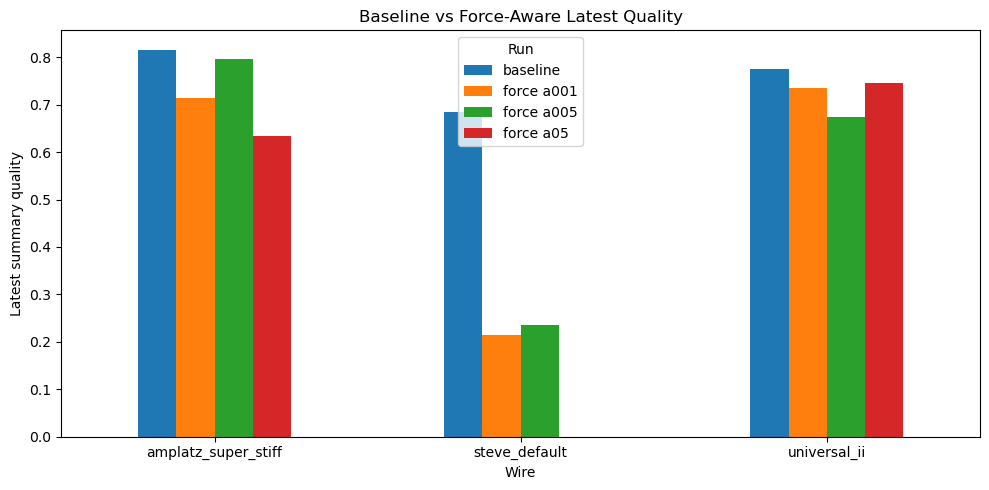

In [11]:
if pd is None or plt is None:
    print("pandas and matplotlib are required for the bar plot; skipping plot.")
else:
    plot_df = df.copy()
    plot_df["label"] = plot_df.apply(
        lambda row: "baseline" if row["comparison_group"] == "baseline" else f"force {row['force_alpha_suffix']}",
        axis=1,
    )

    pivot = plot_df.pivot_table(index="wire_name", columns="label", values="summary_latest_quality", aggfunc="first")
    ax = pivot.plot(kind="bar", figsize=(10, 5), rot=0)
    ax.set_ylabel("Latest summary quality")
    ax.set_xlabel("Wire")
    ax.set_title("Baseline vs Force-Aware Latest Quality")
    ax.legend(title="Run")
    plt.tight_layout()


## Force-Penalty Diagnostics

These metrics only exist for the force-aware runs that have `reward_eval_*.csv` files in the archive.

In [10]:
force_columns = [
    'wire_name',
    'force_alpha_suffix',
    'latest_reward_eval_file',
    'eval_episode_count',
    'eval_target_success_rate',
    'eval_mean_total_reward',
    'eval_mean_force_penalty',
    'eval_nonzero_force_penalty_frac',
    'eval_mean_wire_force_normal_max_N',
    'eval_max_wire_force_normal_max_N',
    'eval_force_unavailable_frac',
]

force_rows = [row for row in rows if row.get("comparison_group") == "force_aware"]
if pd is None:
    [{column: row.get(column) for column in force_columns} for row in force_rows]
else:
    force_df = df[df["comparison_group"] == "force_aware"].copy()
    force_df[force_columns].sort_values(["wire_name", "force_alpha_suffix"]).reset_index(drop=True)


## Notes

- Baseline rows come from the standard-J best agents in `data/wire_registry/*/wire_versions/standard_j/agents/*/agent.json`.
- Baseline archives do not currently expose per-evaluation `reward_eval_*.csv` files in the same way, so force-specific diagnostics are unavailable for them.
- Force-aware rows are loaded from `data/archive/agents/force_aware/*` and will expand automatically as more runs are synced.